# Experiment on new data configuration - Secondary follow recommendation

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import networkx as nx

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import igraph as ig
import leidenalg as la

## Data loading and checking

In [2]:
# database connection
conn = sqlite3.connect("data/database_server_FRS.db")

# List available tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

               name
0         user_mgmt
1            follow
2   recommendations
3            rounds
4     user_interest
5         interests
6              post
7          mentions
8          emotions
9     post_hashtags
10         hashtags
11        reactions


In [3]:
follow = pd.read_sql("SELECT * FROM follow", conn)
follow.head()

,id,user_id,follower_id,action,round
0,1,673,171,follow,1
1,2,485,673,follow,1
2,3,907,485,follow,1
3,4,455,74,follow,2
4,5,621,455,follow,2


In [4]:
users = pd.read_sql("SELECT * FROM user_mgmt", conn)
users.head()

,id,username,email,password,user_type,leaning,age,oe,co,ex,...,frecsys_type,round_actions,gender,nationality,toxicity,is_page,left_on,daily_activity_level,profession,activity_profile
0,1,Admin,admin@y-not.social,pbkdf2:sha256:260000$fSQmzFBLkE0l3TGt$21fb8dba...,user,none,0,None,None,None,...,default,3,None,None,none,0,None,1,None,None
1,13,NancyHayes,NancyHayes@ysocial.it,NancyHayes,llama3.2:latest,democrat,79,consistent/cautious,extravagant/careless,solitary/reserved,...,FollowRecSys,5,female,American,low,0,None,1,Archaeologist,Coffee Break User
2,2,CassandraRichards,CassandraRichards@ysocial.it,CassandraRichards,llama3.2:latest,democrat,30,consistent/cautious,extravagant/careless,solitary/reserved,...,FollowRecSys,4,female,American,low,0,None,4,Yoga Instructor,Coffee Break User
3,9,AdamCastro,AdamCastro@ysocial.it,AdamCastro,llama3.2:latest,democrat,28,inventive/curious,extravagant/careless,solitary/reserved,...,FollowRecSys,2,male,American,low,0,None,1,Real Estate Agent,Always On
4,3,JaneFitzgerald,JaneFitzgerald@ysocial.it,JaneFitzgerald,llama3.2:latest,democrat,15,inventive/curious,efficient/organized,solitary/reserved,...,FollowRecSys,7,female,American,low,0,None,1,Student,Always On


In [5]:
rounds = pd.read_sql("SELECT * FROM rounds", conn)
rounds.head()

,id,day,hour
0,1,0,0
1,2,0,1
2,3,0,2
3,4,0,3
4,5,0,4


In [6]:
posts = pd.read_sql("SELECT * FROM post", conn)
posts.head()

,id,tweet,post_img,user_id,comment_to,thread_id,round,news_id,shared_from,image_id,reaction_count
0,569,I am not allowed to view external links or con...,None,422,565,565,12,None,-1,None,0
1,13,"Just watched an epic fencing match! I mean, ha...",None,675,-1,13,1,None,-1,None,0
2,4,@SoccerMara I think Manchester United will str...,None,805,1,1,1,None,-1,None,0
3,20,@JuliaNelson Fencing may use swords as weapons...,None,936,13,13,1,None,-1,None,0
4,5,"@SoccerMara I agree, let's take a moment to ac...",None,805,1,1,1,None,-1,None,0


## Connective components

In [7]:
G_follow = nx.from_pandas_edgelist(follow, source="follower_id", target="user_id", create_using=nx.DiGraph())

In [8]:
print(f"Liczba wierzchołków: {len(G_follow)}")
print(f"Liczba krawędzi: {G_follow.size()}")

Liczba wierzchołków: 945
Liczba krawędzi: 13304


In [9]:
components = list(nx.weakly_connected_components(G_follow))
sizes = [len(c) for c in components]

print("Number of components:", len(components))
print("Components sizes:", sizes)

Number of components: 2
Components sizes: [943, 2]


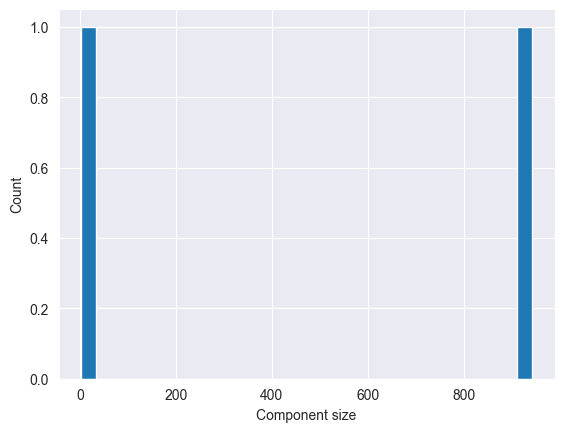

In [10]:
plt.hist(sizes, bins=30)
plt.xlabel("Component size")
plt.ylabel("Count")
plt.show()

We can work on the largest component.

In [11]:
largest_cc = max(nx.weakly_connected_components(G_follow), key=len)
G_lcc = G_follow.subgraph(largest_cc).copy()

In [12]:
print(f"Liczba wierzchołków: {len(G_lcc)}")
print(f"Liczba krawędzi: {G_lcc.size()}")

Liczba wierzchołków: 943
Liczba krawędzi: 13303


## The same experiments on other configuration

In [14]:
print(pd.read_sql("SELECT COUNT(DISTINCT day) FROM rounds;", conn))

   COUNT(DISTINCT day)
0                  102


102 days of simulation.

In [15]:
users.drop([0], inplace=True) # delete Admin
users.head()

,id,username,email,password,user_type,leaning,age,oe,co,ex,...,frecsys_type,round_actions,gender,nationality,toxicity,is_page,left_on,daily_activity_level,profession,activity_profile
1,13,NancyHayes,NancyHayes@ysocial.it,NancyHayes,llama3.2:latest,democrat,79,consistent/cautious,extravagant/careless,solitary/reserved,...,FollowRecSys,5,female,American,low,0,None,1,Archaeologist,Coffee Break User
2,2,CassandraRichards,CassandraRichards@ysocial.it,CassandraRichards,llama3.2:latest,democrat,30,consistent/cautious,extravagant/careless,solitary/reserved,...,FollowRecSys,4,female,American,low,0,None,4,Yoga Instructor,Coffee Break User
3,9,AdamCastro,AdamCastro@ysocial.it,AdamCastro,llama3.2:latest,democrat,28,inventive/curious,extravagant/careless,solitary/reserved,...,FollowRecSys,2,male,American,low,0,None,1,Real Estate Agent,Always On
4,3,JaneFitzgerald,JaneFitzgerald@ysocial.it,JaneFitzgerald,llama3.2:latest,democrat,15,inventive/curious,efficient/organized,solitary/reserved,...,FollowRecSys,7,female,American,low,0,None,1,Student,Always On
5,4,BrianTaylor,BrianTaylor@ysocial.it,BrianTaylor,llama3.2:latest,democrat,18,inventive/curious,efficient/organized,solitary/reserved,...,FollowRecSys,7,male,American,low,0,None,1,Cashier,Community Builder


## Create personae

### Professions mapping

Be careful there could be new professions in dataset.

In [16]:
cluster_map = {
    "Professor": "Science_Academia",
    "Researcher": "Science_Academia",
    "Scientist": "Science_Academia",
    "Teacher": "Science_Academia",
    "Tutor": "Science_Academia",
    "Librarian": "Science_Academia",
    "School Counselor": "Science_Academia",
    "Psychologist": "Science_Academia",
    "Archaeologist": "Science_Academia",
    "Biologist": "Science_Academia",
    "Astronomer": "Science_Academia",
    "Lab Technician": "Science_Academia",
    "Special Education Teacher": "Science_Academia",
    "Student": "Science_Academia",

    "Surgeon": "Healthcare",
    "Nurse": "Healthcare",
    "Doctor": "Healthcare",
    "Dentist": "Healthcare",
    "Physiotherapist": "Healthcare",
    "Paramedic": "Healthcare",
    "Veterinarian": "Healthcare",
    "Medical Assistant": "Healthcare",
    "Home Health Aide": "Healthcare",
    "Caregiver": "Healthcare",
    "Pharmacist": "Healthcare",

    "Personal Trainer": "Sport",
    "Yoga Instructor": "Sport",
    "Athlete": "Sport",
    "Sports Coach": "Sport",
    "Referee": "Sport",

    "IT Technician": "Technology",
    "Network Administrator": "Technology",
    "Software Engineer": "Technology",
    "Web Developer": "Technology",
    "Cybersecurity Analyst": "Technology",
    "Data Scientist": "Technology",
    "Robotics Engineer": "Technology",
    "Electrical Engineer": "Technology",
    "Mechanical Engineer": "Technology",
    "Civil Engineer": "Technology",

    "Lawyer": "Law_Finance_Admin",
    "Judge": "Law_Finance_Admin",
    "Paralegal": "Law_Finance_Admin",
    "Accountant": "Law_Finance_Admin",
    "Human Resources Manager": "Law_Finance_Admin",
    "Business Consultant": "Law_Finance_Admin",
    "Financial Analyst": "Law_Finance_Admin",
    "Stockbroker": "Law_Finance_Admin",
    "Bank Teller": "Law_Finance_Admin",
    "Entrepreneur": "Law_Finance_Admin",
    "Real Estate Agent": "Law_Finance_Admin",

    "Dancer": "Arts_Media",
    "Musician": "Arts_Media",
    "Photographer": "Arts_Media",
    "Filmmaker": "Arts_Media",
    "Actor": "Arts_Media",
    "Comedian": "Arts_Media",
    "Tattoo Artist": "Arts_Media",
    "Writer": "Arts_Media",
    "Graphic Designer": "Arts_Media",
    "Clown": "Arts_Media",
    "Fortune Teller": "Arts_Media",
    "Journalist": "Arts_Media",
    "Street Performer": "Arts_Media",

    "Construction Worker": "Skilled_Trades",
    "Mechanic": "Skilled_Trades",
    "Electrician": "Skilled_Trades",
    "Plumber": "Skilled_Trades",
    "Welder": "Skilled_Trades",
    "Blacksmith": "Skilled_Trades",
    "Handyman": "Skilled_Trades",
    "Carpenter": "Skilled_Trades",
    "Textile Worker": "Skilled_Trades",
    "Factory Worker": "Skilled_Trades",
    "Miner": "Skilled_Trades",
    "Painter": "Skilled_Trades",
    "Day Laborer": "Skilled_Trades",
    "Garbage Collector": "Skilled_Trades",

    "Farmer": "Agriculture",
    "Rancher": "Agriculture",
    "Beekeeper": "Agriculture",
    "Agricultural Worker": "Agriculture",
    "Winemaker": "Agriculture",
    "Fisherman": "Agriculture",

    "Truck Driver": "Transport",
    "Taxi Driver": "Transport",
    "Courier": "Transport",
    "Food Delivery Driver": "Transport",
    "Dock Worker": "Transport",
    "Railway Worker": "Transport",
    "Pilot": "Transport",
    "Postal Worker": "Transport",
    "Flight Attendant": "Transport",

    "Cashier": "Retail_Service",
    "Retail Salesperson": "Retail_Service",
    "Barista": "Retail_Service",
    "Waiter": "Retail_Service",
    "Bartender": "Retail_Service",
    "Hotel Receptionist": "Retail_Service",
    "Janitor": "Retail_Service",
    "Housekeeper": "Retail_Service",
    "Call Center Agent": "Retail_Service",
    "Customer Service Representative": "Retail_Service",
    "Fast Food Worker": "Retail_Service",
    "Baker": "Retail_Service",
    "Butcher": "Retail_Service",
    "Chef": "Retail_Service",
    "Babysitter": "Retail_Service",
    "Dog Walker": "Retail_Service",
    "Personal Assistant": "Retail_Service",

    "Police Officer": "Security",
    "Security Guard": "Security",
    "Corrections Officer": "Security",
    "Firefighter": "Security",
    "Military Officer": "Security",
    "Soldier": "Security",

    "Escort": "Alternative",
    "Scavenger": "Alternative",
    "Street Vendor": "Alternative",
    "Busker": "Alternative",
    "Gambler": "Alternative",
    None: "Alternative"
}

In [17]:
not_in_map = set()

for p in users['profession']:
    if p not in list(cluster_map.keys()):
        not_in_map.add(p)

not_in_map

set()

### Functions

In [18]:
def encode_age(age):
    if age < 30: return "young"
    elif age < 50: return "middle"
    else: return "old"

In [19]:
def cramers_v_matrix(df, label=""):
    """
    Plots and returns Cramers-V-Matrix.
    """

    def cramers_v(x, y):
        confusion_matrix = pd.crosstab(x, y)
        chi2 = chi2_contingency(confusion_matrix)[0]
        n = confusion_matrix.sum().sum()
        r, k = confusion_matrix.shape
        return np.sqrt(chi2 / (n * (min(k-1, r-1))))

    # Build correlation matrix
    cols = df.columns
    matrix = pd.DataFrame(index=cols, columns=cols)

    for i in cols:
        for j in cols:
            matrix.loc[i, j] = cramers_v(df[i], df[j])

    cv_matrix = matrix.astype(float)

    title = f"Cramér's V Attribute Correlation Matrix for {label}" if label != "" \
        else "Cramér's V Attribute Correlation Matrix"

    plt.figure(figsize=(8,6))
    sns.heatmap(cv_matrix, annot=True, cmap="Blues")
    plt.title(title)
    plt.show()

    return cv_matrix

### Clustering

In [23]:
personae = users[['id', 'age', 'oe', 'co', 'ex', 'ag', 'ne', 'profession']].copy()
# 'gender', 'leaning', 'education_level',

personae = personae.rename(columns={
    'oe': 'openness',
    'co': 'conscientiousness',
    'ex': 'extroversion',
    'ag': 'agreeableness',
    'ne': 'neuroticism'
})

personae['age'] = personae['age'].astype(int)
personae['age'] = personae['age'].apply(encode_age)

personae['profession'] = personae['profession'].map(cluster_map)

personae.head()

,id,age,openness,conscientiousness,extroversion,agreeableness,neuroticism,profession
1,13,old,consistent/cautious,extravagant/careless,solitary/reserved,friendly/compassionate,resilient/confident,Science_Academia
2,2,middle,consistent/cautious,extravagant/careless,solitary/reserved,friendly/compassionate,sensitive/nervous,Sport
3,9,young,inventive/curious,extravagant/careless,solitary/reserved,friendly/compassionate,sensitive/nervous,Law_Finance_Admin
4,3,young,inventive/curious,efficient/organized,solitary/reserved,critical/judgmental,sensitive/nervous,Science_Academia
5,4,young,inventive/curious,efficient/organized,solitary/reserved,friendly/compassionate,resilient/confident,Retail_Service


In this simulation experiment all users are democrat and has level of education = high-school

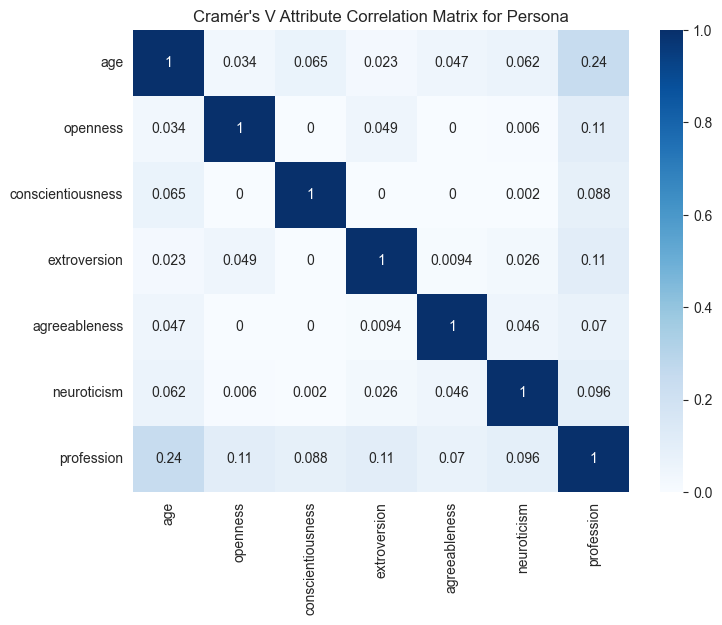

In [24]:
feature_cols = ['age', 'openness', 'conscientiousness', 'extroversion', 'agreeableness',
                'neuroticism', 'profession'] # 'gender', 'leaning', 'education_level',
features_df = personae[feature_cols].copy()

cvmatrix = cramers_v_matrix(features_df, label="Persona")

In [25]:
encoded_personae = pd.get_dummies(personae, columns=feature_cols, drop_first=False)

print(encoded_personae.shape)
encoded_personae.head()

(1000, 26)


,id,age_middle,age_old,age_young,openness_consistent/cautious,openness_inventive/curious,conscientiousness_efficient/organized,conscientiousness_extravagant/careless,extroversion_outgoing/energetic,extroversion_solitary/reserved,...,profession_Arts_Media,profession_Healthcare,profession_Law_Finance_Admin,profession_Retail_Service,profession_Science_Academia,profession_Security,profession_Skilled_Trades,profession_Sport,profession_Technology,profession_Transport
1,13,False,True,False,True,False,False,True,False,True,...,False,False,False,False,True,False,False,False,False,False
2,2,True,False,False,True,False,False,True,False,True,...,False,False,False,False,False,False,False,True,False,False
3,9,False,False,True,False,True,False,True,False,True,...,False,False,True,False,False,False,False,False,False,False
4,3,False,False,True,False,True,True,False,False,True,...,False,False,False,False,True,False,False,False,False,False
5,4,False,False,True,False,True,True,False,False,True,...,False,False,False,True,False,False,False,False,False,False


In [26]:
features = encoded_personae.copy().drop(['id'], axis=1)

In [27]:
scores = []

for k in range(2, 16):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(features)
    score = silhouette_score(features, labels)
    scores.append(score)
    print(f"k={k} silhouette={score:.4f}")

k=2 silhouette=0.0871
k=3 silhouette=0.1011
k=4 silhouette=0.1395
k=5 silhouette=0.0983
k=6 silhouette=0.0948
k=7 silhouette=0.1222
k=8 silhouette=0.1342
k=9 silhouette=0.1272
k=10 silhouette=0.1183
k=11 silhouette=0.1326
k=12 silhouette=0.1319
k=13 silhouette=0.1342
k=14 silhouette=0.1422
k=15 silhouette=0.1416


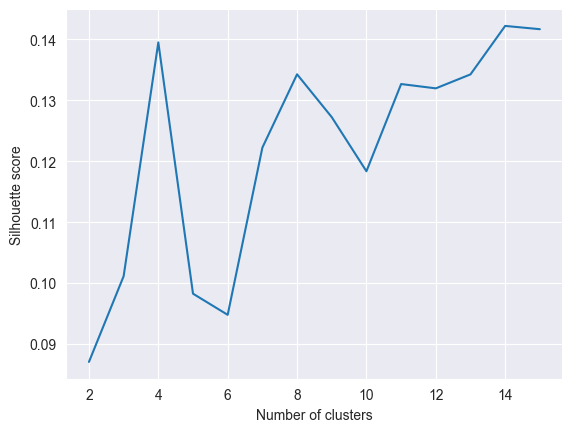

In [28]:
plt.plot(range(2, 16), scores)
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.show()

In this case we create 4 different personae.

In [29]:
k_best = 4

kmeans = KMeans(n_clusters=k_best, random_state=42)
personae['persona'] = kmeans.fit_predict(features)

personae['persona'].value_counts()

persona
1    269
0    262
3    238
2    231
Name: count, dtype: int64

In [30]:
persona_map = {
    0: 'Persona_1',
    1: 'Persona_2',
    2: 'Persona_3',
    3: 'Persona_4',
    # 4: 'Persona_5',
}

personae['persona'] = personae['persona'].map(persona_map)

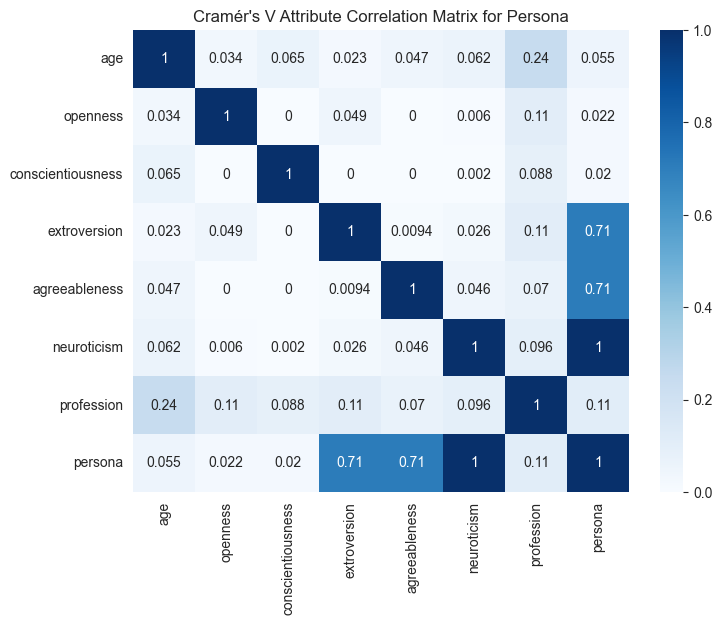

In [31]:
features_df['persona'] = personae['persona']

cvmatrix = cramers_v_matrix(features_df, label="Persona")

We have to remove gender, but later.

### Persona validation

In [32]:
# gender = pd.crosstab(personae['persona'], personae['gender'], normalize='index')
openness = pd.crosstab(personae['persona'], personae['openness'], normalize='index')
conscientiousness = pd.crosstab(personae['persona'], personae['conscientiousness'], normalize='index')
extroversion = pd.crosstab(personae['persona'], personae['extroversion'], normalize='index')
agreeableness = pd.crosstab(personae['persona'], personae['agreeableness'], normalize='index')
neuroticism = pd.crosstab(personae['persona'], personae['neuroticism'], normalize='index')
# leaning = pd.crosstab(personae['persona'], personae['leaning'], normalize='index')

persona_description = (#gender.join(openness, on=['persona']).
                        openness.
                       join(conscientiousness, on=['persona']).
                       join(extroversion, on=['persona']).
                       join(agreeableness, on=['persona']).
                       join(neuroticism, on=['persona'])
                       # join(leaning, on=['persona'])
                       )

persona_description

,consistent/cautious,inventive/curious,efficient/organized,extravagant/careless,outgoing/energetic,solitary/reserved,critical/judgmental,friendly/compassionate,resilient/confident,sensitive/nervous
persona,,,,,,,,,,
Persona_1,0.526718,0.473282,0.519084,0.480916,0.000000,1.000000,0.507634,0.492366,1.0,0.0
Persona_2,0.520446,0.479554,0.505576,0.494424,0.509294,0.490706,1.000000,0.000000,0.0,1.0
Persona_3,0.497835,0.502165,0.519481,0.480519,0.497835,0.502165,0.000000,1.000000,0.0,1.0
Persona_4,0.508403,0.491597,0.495798,0.504202,1.000000,0.000000,0.470588,0.529412,1.0,0.0


In [33]:
def persona_significance(df, col):
    table = pd.crosstab(df['persona'], df[col])
    chi2, p, dof, expected = chi2_contingency(table)
    return p

for col in feature_cols:
    print(col, persona_significance(personae, col))

age 0.4264136441858052
openness 0.9219905548731512
conscientiousness 0.9437832846153105
extroversion 5.02277238184282e-108
agreeableness 3.731070727370612e-108
neuroticism 1.7994208765314067e-216
profession 0.2857099628586482


| Persona | Label                     | Key Identity                                             |
|--------:|---------------------------|----------------------------------------------------------|
| 1       | Reserved Analyst          | Solitary, structured, critical, emotionally controlled   |
| 2       | Curious Extrovert         | Outgoing, inventive, organized, emotionally responsive   |
| 3       | Expressive Socialite      | Outgoing, emotional, spontaneous, feeling-driven         |
| 4       | Quiet Stabilizer          | Solitary, balanced, emotionally stable, reflective       |


### Follow analysis

In [34]:
# check number of followings
actions_sum = pd.read_sql("SELECT COUNT(id) as all_actions FROM follow;", conn)
follow_action = pd.read_sql("SELECT COUNT(id) as follow FROM follow WHERE action='follow';", conn)
print(f"All actions: {actions_sum['all_actions']}\n"
      f"Follow action: {follow_action['follow']}\n"
      f"Unfollow actions: {actions_sum['all_actions'] - follow_action['follow']}")

All actions: 0    20659
Name: all_actions, dtype: int64
Follow action: 0    15716
Name: follow, dtype: int64
Unfollow actions: 0    4943
dtype: int64


In [35]:
pd.read_sql("SELECT COUNT(DISTINCT user_id) FROM follow;", conn)

,COUNT(DISTINCT user_id)
0,891


In [36]:
avg_deg = sum(dict(G_follow.degree()).values()) / G_follow.number_of_nodes()
dens = nx.density(G_follow)
# largest connected component -> diameter !!!
diam = nx.diameter(G_lcc.to_undirected()) # Longest shortest path between any two nodes
print(f"Mean degree: {avg_deg:.2f}, Density: {dens:.4f}, Diameter: {diam}")

Mean degree: 28.16, Density: 0.0149, Diameter: 6


In [82]:
# For directed graphs:
in_deg = dict(G_follow.in_degree())
out_deg = dict(G_follow.out_degree())

# Convert to dataframe
deg_df = pd.DataFrame({
    'node': list(G_follow.nodes()),
    'in_degree': [in_deg.get(n, 0) for n in G_follow.nodes()],
    'out_degree': [out_deg.get(n, 0) for n in G_follow.nodes()],
    'total_degree': [in_deg.get(n, 0) + out_deg.get(n, 0) for n in G_follow.nodes()]
})

print(f"Mean total degree: {deg_df['total_degree'].mean()}\n"
      f"Mean in_degree: {deg_df['in_degree'].mean()}\n"
      f"Mean out_degree: {deg_df['out_degree'].mean()}\n")

print(f"Median total degree: {deg_df['total_degree'].median()}\n"
      f"Median in_degree: {deg_df['in_degree'].median()}\n"
      f"Median out_degree: {deg_df['out_degree'].median()}\n")

deg_df.sort_values('total_degree', ascending=False).head()

Mean total degree: 28.156613756613755
Mean in_degree: 14.078306878306877
Mean out_degree: 14.078306878306877

Median total degree: 9.0
Median in_degree: 4.0
Median out_degree: 5.0



,node,in_degree,out_degree,total_degree
40,854,199,147,346
7,771,174,163,337
146,901,178,150,328
1,673,169,131,300
123,877,170,122,292


We use *to_undirected()*, because some metrics require strongly connected graphs (eigenvector_centrality, average_shortest_path)

In [90]:
bet = nx.betweenness_centrality(G_lcc)

eig = nx.eigenvector_centrality_numpy(G_lcc.to_undirected())

centrality_df = pd.DataFrame({
    'node': list(G_lcc.nodes()),
    'betweenness': [bet.get(n, 0) for n in G_lcc.nodes()],
    'eigenvector': [eig.get(n, 0) for n in G_lcc.nodes()],
})
centrality_df.head()

,node,betweenness,eigenvector
0,171,0.022434,0.114271
1,673,0.039794,0.129742
2,485,0.011184,0.103260
3,907,0.007393,0.088726
4,74,0.001629,0.042832


Alternative metrics for not connected graph

In [87]:
pagerank = nx.pagerank(G_follow, alpha=0.85)
pagerank

{171: 0.008126766374099556,
 673: 0.010801023384806126,
 485: 0.005400263002316178,
 907: 0.004644620728166137,
 74: 0.001663457158882683,
 455: 0.0025798522847242837,
 621: 0.004530965726289474,
 771: 0.01113305790700753,
 867: 0.003190491651887403,
 284: 0.00843950054375782,
 20: 0.0035165919443214187,
 910: 0.004526458477106042,
 674: 0.006469205287849134,
 498: 0.00678768741833774,
 37: 0.0009593547682694566,
 484: 0.002249251629130798,
 263: 0.0010969186786614212,
 888: 0.005076554701611773,
 47: 0.007246279725592431,
 679: 0.008519326475359896,
 692: 0.001141431066814892,
 869: 0.0004251263610691227,
 595: 0.0002979281298260496,
 314: 0.0004521035535964234,
 96: 0.0003665953093478433,
 814: 0.001399770449797816,
 671: 0.0005222532333430583,
 64: 0.0005263516448505242,
 829: 0.00032925509685980694,
 903: 0.0072118049707368195,
 212: 0.00043649932692089435,
 624: 0.00936625096852335,
 949: 0.005349960028025667,
 865: 0.009318655377099335,
 6: 0.0038110286555077424,
 958: 0.00396893

In [89]:
nx.average_shortest_path_length(G_lcc.to_undirected())

2.6392099118997283

In [91]:
# Convert from networkx to igraph
ig_graph = ig.Graph.TupleList(G_follow.edges(), directed=True)

# Compute core numbers (k-shell decomposition)
core_numbers = ig_graph.coreness(mode="ALL")

# Attach to dataframe
kcore_df = pd.DataFrame({
    'node': ig_graph.vs['name'],
    'kcore': core_numbers
})
kcore_df.head()

,node,kcore
0,171,59
1,673,59
2,242,59
3,839,59
4,592,33


In [94]:
# Using same igraph object

partition = la.find_partition(ig_graph, partition_type=la.ModularityVertexPartition)
modularity = partition.modularity

community_df = pd.DataFrame({
    'node': ig_graph.vs['name'],
    'community': partition.membership
})

print(f"Modularity score: {modularity:.3f}")
community_df.head()

Modularity score: 0.138


,node,community
0,171,9
1,673,8
2,242,5
3,839,4
4,592,6


### Adding persona

In [37]:
# mapping
persona_dict = personae.set_index('id')['persona'].to_dict()

# add attributes to nodes
nx.set_node_attributes(G_follow, persona_dict, "persona")

# check
for node in list(G_follow.nodes())[:5]:
    print(node, G_follow.nodes[node])

171 {'persona': 'Persona_1'}
673 {'persona': 'Persona_4'}
485 {'persona': 'Persona_2'}
907 {'persona': 'Persona_3'}
74 {'persona': 'Persona_2'}


In [38]:
assortativity = nx.attribute_assortativity_coefficient(G_follow, 'persona')
print("Persona assortativity:", assortativity)

Persona assortativity: -0.002624668062462363


Better but still random - in reality it's normal

In [97]:
metrics = (
    deg_df
    .merge(centrality_df, on='node', how='left')
    .merge(kcore_df, on='node', how='left')
    .merge(community_df, on='node', how='left')
)
metrics.head()

,node,in_degree,out_degree,total_degree,betweenness,eigenvector,kcore,community
0,171,124,98,222,0.022434,0.114271,59,9
1,673,169,131,300,0.039794,0.129742,59,8
2,485,88,81,169,0.011184,0.103260,59,4
3,907,76,69,145,0.007393,0.088726,59,5
4,74,26,30,56,0.001629,0.042832,40,8


In [98]:
metrics.describe()

,node,in_degree,out_degree,total_degree,betweenness,eigenvector,kcore,community
count,945.000000,945.000000,945.000000,945.000000,943.000000,943.000000,945.000000,945.000000
mean,501.916402,14.078307,14.078307,28.156614,0.001740,0.017556,15.400000,3.706878
std,289.447081,26.488409,23.889315,49.966608,0.005062,0.027441,17.380488,2.802051
min,2.000000,0.000000,0.000000,1.000000,0.000000,0.000002,1.000000,0.000000
25%,252.000000,2.000000,2.000000,4.000000,0.000006,0.002273,4.000000,1.000000
50%,501.000000,4.000000,5.000000,9.000000,0.000090,0.006179,8.000000,3.000000
75%,753.000000,12.000000,13.000000,24.000000,0.001123,0.016508,18.000000,6.000000
max,1001.000000,199.000000,163.000000,346.000000,0.051035,0.143889,59.000000,10.000000


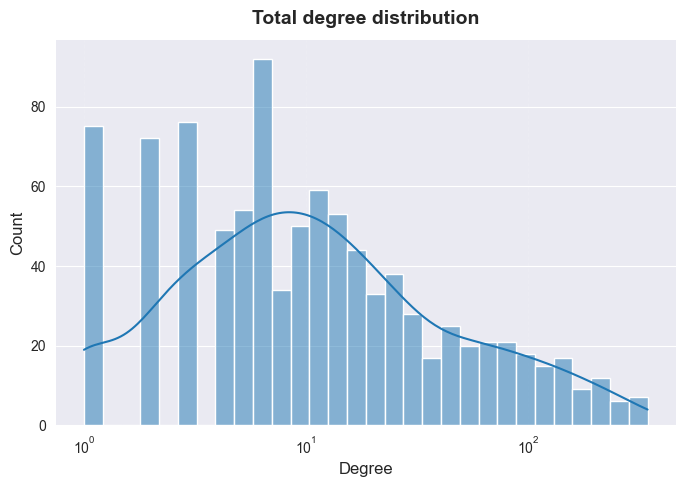

In [102]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
sns.histplot(metrics['total_degree'], bins=30, kde=True, ax=ax, log_scale=True) # color=sns.color_palette("pastel")[0]  color="#ff9ecb",
ax.set_title("Total degree distribution", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("Degree", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.grid(axis="x", linestyle="--", alpha=0.1)
sns.despine(left=True, bottom=True)
plt.show()

C:\Users\magda\Programs\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


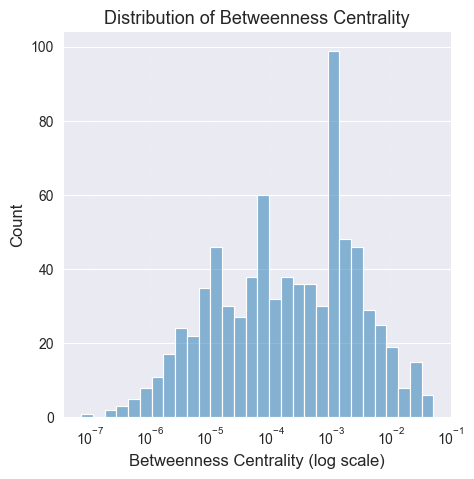

In [100]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.histplot(metrics['betweenness'], bins=30, kde=True, log_scale=True, ax=ax)
ax.set_xlabel("Betweenness Centrality (log scale)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Distribution of Betweenness Centrality", fontsize=13)
ax.grid(axis="x", linestyle="--", alpha=0.1)
sns.despine(left=True, bottom=True)
plt.show()

In [101]:
# Compare groups
metrics.groupby('community')['total_degree'].median().sort_values(ascending=False)

community
1     14.0
3     11.0
0     10.0
2     10.0
4     10.0
6     10.0
5      8.0
8      7.0
7      6.0
9      4.5
10     1.0
Name: total_degree, dtype: float64

### Metrics vs Persona

| Metric      | Meaning                 |
| ----------- | ----------------------- |
| In-degree   | Popularity              |
| Out-degree  | Activity                |
| Betweenness | Brokerage / bridging    |
| PageRank    | Influence               |
| k-core      | Structural embeddedness |

Usually you’ll see:
- extroverted personas → high out-degree
- analytical personas → high betweenness
- empathic personas → high PageRank

In [39]:
in_deg = dict(G_follow.in_degree())
out_deg = dict(G_follow.out_degree())
total_deg = dict(G_follow.degree())

betweenness = nx.betweenness_centrality(G_follow, normalized=True)
pagerank = nx.pagerank(G_follow, alpha=0.85)

kcore = nx.core_number(G_follow.to_undirected())

metrics = pd.DataFrame({
    'node': list(G_follow.nodes()),
    'persona': [G_follow.nodes[n].get('persona') for n in G_follow.nodes()],
    'in_degree': [in_deg[n] for n in G_follow.nodes()],
    'out_degree': [out_deg[n] for n in G_follow.nodes()],
    'total_degree': [total_deg[n] for n in G_follow.nodes()],
    'betweenness': [betweenness[n] for n in G_follow.nodes()],
    'pagerank': [pagerank[n] for n in G_follow.nodes()],
    'kcore': [kcore[n] for n in G_follow.nodes()]
})

In [40]:
persona_summary = metrics.groupby('persona').agg(
    n_nodes=('node', 'count'),
    mean_in_degree=('in_degree', 'mean'),
    mean_out_degree=('out_degree', 'mean'),
    mean_total_degree=('total_degree', 'mean'),
    mean_betweenness=('betweenness', 'mean'),
    median_betweenness=('betweenness', 'median'),
    mean_pagerank=('pagerank', 'mean'),
    mean_kcore=('kcore', 'mean')
).sort_values('mean_pagerank', ascending=False)

persona_summary

,n_nodes,mean_in_degree,mean_out_degree,mean_total_degree,mean_betweenness,median_betweenness,mean_pagerank,mean_kcore
persona,,,,,,,,
Persona_3,220,15.277273,13.859091,29.136364,0.001897,0.000134,0.001148,13.140909
Persona_2,252,14.587302,15.527778,30.115079,0.001906,0.000085,0.001082,13.154762
Persona_1,250,13.996000,14.640000,28.636000,0.001671,0.000082,0.001048,13.228000
Persona_4,223,12.412556,12.026906,24.439462,0.001426,0.000094,0.000955,11.878924


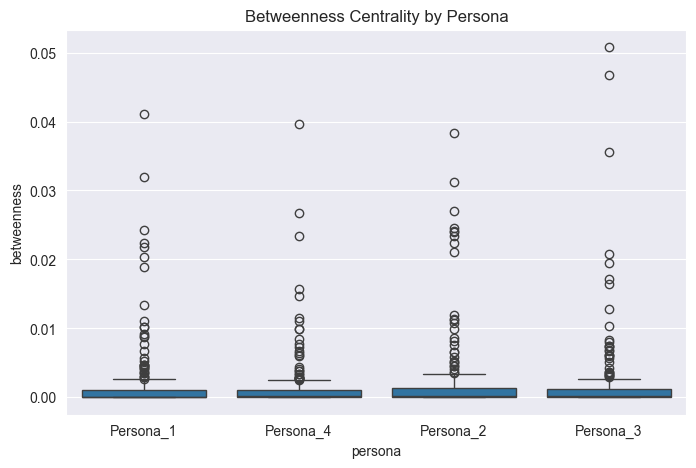

In [42]:
metrics.groupby('persona')['betweenness'].quantile([0.25, 0.5, 0.75])

plt.figure(figsize=(8,5))
sns.boxplot(data=metrics, x='persona', y='betweenness')
plt.title("Betweenness Centrality by Persona")
plt.show()

In [46]:
# Top influencers per persona
top_nodes = metrics.sort_values('pagerank', ascending=False)
top_nodes.groupby('persona').head(5)

,node,persona,in_degree,out_degree,total_degree,betweenness,pagerank,kcore
40,854,Persona_3,199,147,346,0.050819,0.012736,43
7,771,Persona_3,174,163,337,0.046813,0.011133,43
123,877,Persona_3,170,122,292,0.035606,0.010976,43
1,673,Persona_4,169,131,300,0.039626,0.010801,43
146,901,Persona_1,178,150,328,0.041061,0.010717,43
31,624,Persona_3,146,96,242,0.020802,0.009366,43
33,865,Persona_1,153,138,291,0.031897,0.009319,43
129,964,Persona_4,147,105,252,0.026750,0.009123,43
48,587,Persona_2,146,144,290,0.038350,0.008698,43
19,679,Persona_2,140,135,275,0.031220,0.008519,43


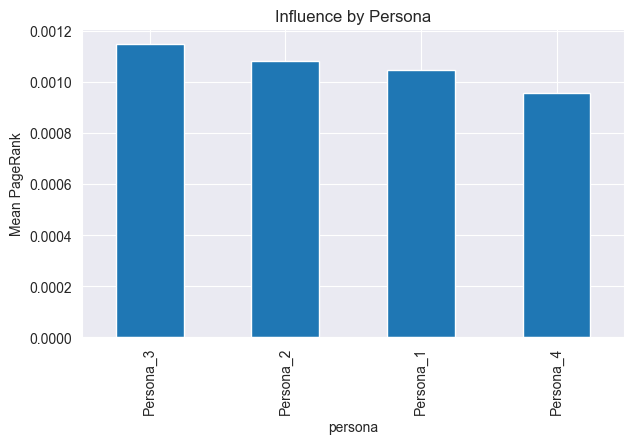

In [45]:
persona_summary['mean_pagerank'].plot(kind='bar', figsize=(7,4))
plt.ylabel("Mean PageRank")
plt.title("Influence by Persona")
plt.show()

**Effect-size check** (Ratio vs global mean)

- '>'1.2 → persona over-represented among influencers

- <0.8 → persona peripheral

In [47]:
global_mean = metrics['pagerank'].mean()

persona_summary['pagerank_ratio'] = (
    persona_summary['mean_pagerank'] / global_mean
)

persona_summary[['mean_pagerank', 'pagerank_ratio']]

,mean_pagerank,pagerank_ratio
persona,,
Persona_3,0.001148,1.084683
Persona_2,0.001082,1.022361
Persona_1,0.001048,0.990245
Persona_4,0.000955,0.902123


**Minimal statistical check**

If p < 0.05 → personas differ structurally.

In [48]:
from scipy.stats import kruskal

groups = [
    metrics[metrics['persona'] == p]['betweenness']
    for p in metrics['persona'].unique()
]

kruskal(*groups)

KruskalResult(statistic=np.float64(1.316240767006786), pvalue=np.float64(0.7252802058986811))